<a href="https://colab.research.google.com/github/fankewe/ml-currency-volatility/blob/main/xgboost_volatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


Price       Adj Close     Close      High       Low      Open  Volume
Date                                                                 
2020-01-01   1.122083  1.122083  1.122838  1.115947  1.122083       0
2020-01-02   1.122083  1.122083  1.122712  1.116682  1.121894       0
2020-01-03   1.117144  1.117144  1.118068  1.112570  1.117081       0
2020-01-06   1.116196  1.116196  1.120825  1.115810  1.116246       0
2020-01-07   1.119799  1.119799  1.119946  1.113487  1.119583       0
XGBoost Evaluation
-------------------
MSE:  0.00000011
RMSE: 0.00033464
MAE:  0.00022885


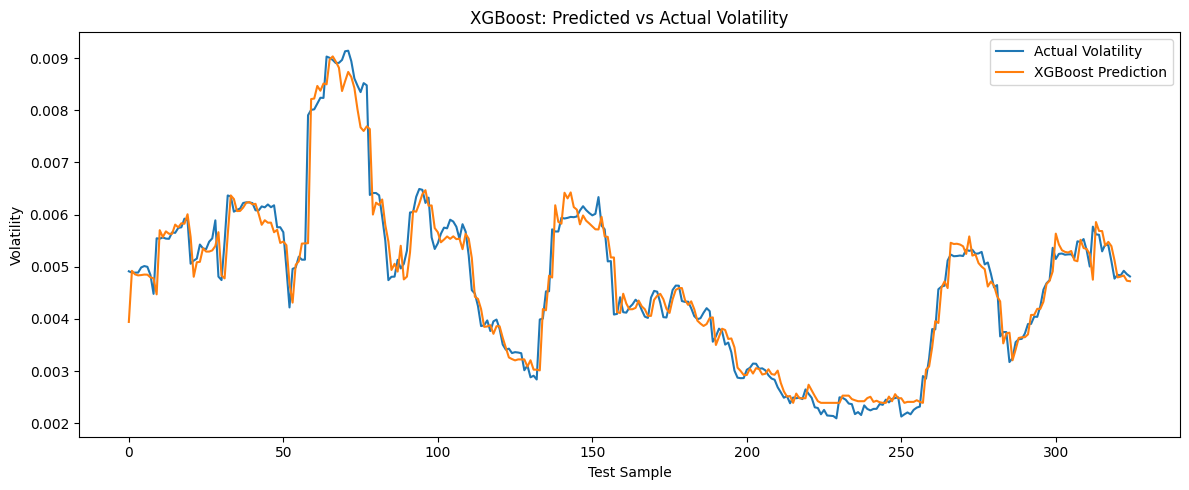

         Feature  Importance
6  volatility_20    0.560576
5  volatility_10    0.325795
4   volatility_5    0.050185
3   return_lag_5    0.020677
0   return_lag_1    0.016534
1   return_lag_2    0.013233
2   return_lag_3    0.012999


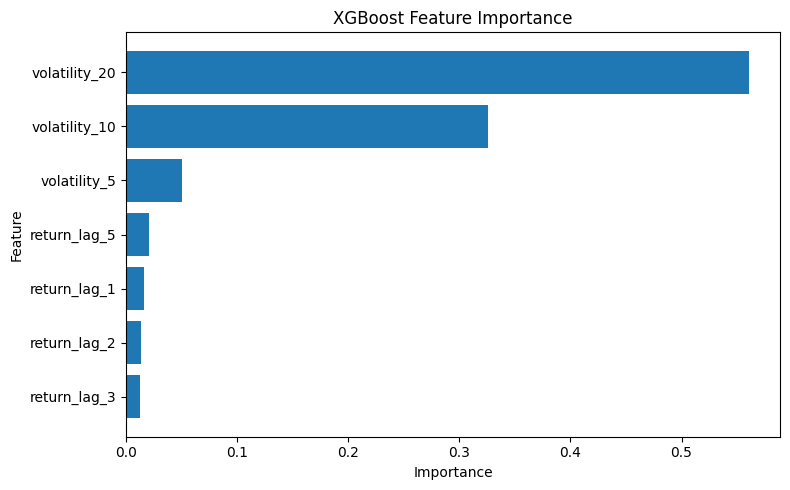

In [1]:
# ===================================
# XGBoost for Currency Volatility
# ===================================

# 1. Install (only needed once in Colab)
!pip install xgboost

# 2. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 3. Download data
df = yf.download("EURUSD=X", start="2020-01-01", auto_adjust=False)

# Fix MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(df.head())

# 4. Data preprocessing
df["price"] = df["Close"]
df["log_price"] = np.log(df["price"])
df["return"] = df["log_price"].diff()

# 5. Feature engineering
df["volatility_5"] = df["return"].rolling(5).std()
df["volatility_10"] = df["return"].rolling(10).std()
df["volatility_20"] = df["return"].rolling(20).std()

df["return_lag_1"] = df["return"].shift(1)
df["return_lag_2"] = df["return"].shift(2)
df["return_lag_3"] = df["return"].shift(3)
df["return_lag_5"] = df["return"].shift(5)

# Target
df["target_volatility"] = df["volatility_20"].shift(-1)

# Clean data
df_model = df.dropna().copy()

# 6. Define features
features = [
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_5",
    "volatility_5",
    "volatility_10",
    "volatility_20"
]

X = df_model[features]
y = df_model["target_volatility"]

# 7. Train-test split (time-series)
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 8. Train XGBoost model
model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# 9. Prediction
y_pred = model.predict(X_test)

# 10. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("XGBoost Evaluation")
print("-------------------")
print(f"MSE:  {mse:.8f}")
print(f"RMSE: {rmse:.8f}")
print(f"MAE:  {mae:.8f}")

# 11. Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual Volatility")
plt.plot(y_pred, label="XGBoost Prediction")

plt.title("XGBoost: Predicted vs Actual Volatility")
plt.xlabel("Test Sample")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()

plt.savefig("xgboost_prediction_vs_actual.png", dpi=300)
plt.show()

# 12. Feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("xgboost_feature_importance.png", dpi=300)
plt.show()